# Accuracy evaluation of Flash Attention

测试C算子与PyTorch官方实现的单头Attention Outputs精度偏差

包括两种不同精度Softmax算子（`fp16`与`fp32`）

Parameters：

- `SEQ_LEN`: 128, 256, 512, 1024, 250 (for padding), 2048
- `BR*BC`: ***所有精度测量数据均在`128x256`尺寸下进行***
- `HEAD_DIM`: 64

Evaluation Metrics:

- Cosine Similarity
- Relative Error
- Maximum Absolute Error

Visualization:

- Error Heatmap / Curve
- Similarity Curve per Token
- Output Value Distribution

In [87]:
import torch
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from typing import Tuple
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [88]:
class AttentionOutput:
    """
    表示单个Attention输出文件并提供加载与误差评估工具

    Args:
        path (str): 输出文件路径，文件名格式应当为"O_{model}_seq{seq_len}_brbc{br}x{bc}.txt"

    Attributes:
        path (Path): 文件路径对象
        file_name (str): 文件名含后缀
        model (str): 模型标识从文件名解析
        seq_len (int): 序列长度从文件名解析
        tile_shape (Tuple[int, int]): 分块形状从文件名解析
        head_dim (int): 头维度
        tensor (torch.Tensor): 输出张量
        shape (Tuple[int, ...]): 张量形状
    """
    def __init__(self, path: str) -> None:
        self.path: Path = Path(path)
        self.file_name: str = self.path.name
        self.model: str = self.path.stem.split("_")[1]
        self.seq_len: int = int(self.path.stem.split("_")[2].replace("seq", ""))
        tile_shape_str = self.path.stem.split("_")[3].replace("brbc", "")
        self.tile_shape: Tuple = tuple(map(int, tile_shape_str.split("x")))
        self.head_dim: int = 64
        self.tensor: torch.Tensor = torch.empty(0)
        self.tensor = self.load_tensor()
        self.shape: Tuple = self.tensor.shape

    def load_tensor(self) -> torch.Tensor:
        """
        从文件读取并缓存输出张量
        Returns:
            torch.Tensor: 读取到的输出张量
        """
        if self.tensor.numel() != 0:
            return self.tensor
        
        if self.path.is_file():
            with self.path.open("r", encoding="utf-8") as f:
                lines = f.read().strip().split("\n\n")
                self.tensor = torch.tensor([list(map(float, line.split())) for line in lines], dtype=torch.float32)
        else:
            raise FileNotFoundError(f"File {self.path} does not exist.")

        return self.tensor
    
    def cos_similarity(self, target: "AttentionOutput") -> torch.Tensor:
        """
        计算与目标输出的逐Token余弦相似度
        Args:
            target (AttentionOutput): 目标参考输出对象
        Returns:
            torch.Tensor: 逐Token余弦相似度
        """    
        if self.shape != target.shape:
            raise ValueError(f"Shape mismatch: {self.shape} vs {target.shape}")
        
        return F.cosine_similarity(self.tensor, target.tensor)
    
    def relative_error(self, target: "AttentionOutput") -> Tuple[float, torch.Tensor]:
        """
        计算输入矩阵的逐Token和Tensor Level相对误差（基于Frobenius 范数）
        Args:
            target (AttentionOutput): 目标参考输出对象
        Returns:
            Tuple[float, torch.Tensor]: 返回一个元组，包含整体矩阵的相对误差和逐Token的相对误差
        """
        if self.shape != target.shape:
            raise ValueError(f"Shape mismatch: {self.shape} vs {target.shape}")
        
        eps = 1e-9
        # Per tensor
        tensor_diff = torch.linalg.matrix_norm(self.tensor - target.tensor)
        tensor_target_norm = torch.linalg.matrix_norm(target.tensor)
        tensor_relative_error = tensor_diff / (tensor_target_norm + eps)
        # Per token
        token_diff = torch.linalg.norm(self.tensor - target.tensor, dim=1)
        token_target_norm = torch.linalg.norm(target.tensor, dim=1)
        token_relative_error = token_diff / (token_target_norm + eps)

        return tensor_relative_error.item(), token_relative_error
    
    def max_abs_error(self, target: "AttentionOutput") -> Tuple[float, torch.Tensor]:
        """
        计算输入矩阵的逐Token和Tensor Level最大绝对误差
        Args:
            target (AttentionOutput): 目标参考输出对象
        Returns:
            Tuple[float, torch.Tensor]: 返回一个元组，包含整体矩阵的最大绝对误差和逐Token的最大绝对误差
        """
        if self.shape != target.shape:
            raise ValueError(f"Shape mismatch: {self.shape} vs {target.shape}")
        
        return torch.max((self.tensor - target.tensor).abs()).item(), torch.max((self.tensor - target.tensor).abs(), dim=1).values


In [89]:
O_c_fp32 = {}
O_c_fp16 = {}
O_python_fp32 = {}
O_python_fp16 = {}
O_golden_fp32 = {}
O_golden_fp16 = {}

for file in Path("data/single_head_outputs/fp32").glob("O_c_*.txt"):
    O_c_fp32[file.stem.split("O_c_")[1]] = AttentionOutput(str(file))

for file in Path("data/single_head_outputs/fp16").glob("O_c_*.txt"):
    O_c_fp16[file.stem.split("O_c_")[1]] = AttentionOutput(str(file))

for file in Path("data/single_head_outputs/fp32").glob("O_python_*.txt"):
    O_python_fp32[file.stem.split("O_python_")[1]] = AttentionOutput(str(file))

for file in Path("data/single_head_outputs/fp16").glob("O_python_*.txt"):
    O_python_fp16[file.stem.split("O_python_")[1]] = AttentionOutput(str(file))

for file in Path("data/single_head_outputs/fp32").glob("O_golden_*.txt"):
    O_golden_fp32[file.stem.split("O_golden_")[1]] = AttentionOutput(str(file))

for file in Path("data/single_head_outputs/fp16").glob("O_golden_*.txt"):
    O_golden_fp16[file.stem.split("O_golden_")[1]] = AttentionOutput(str(file))

O_c_fp32, O_c_fp16, O_python_fp32, O_python_fp16, O_golden_fp32, O_golden_fp16

({'seq1024_brbc128x128': <__main__.AttentionOutput at 0x18eab0bb230>,
  'seq1024_brbc128x256': <__main__.AttentionOutput at 0x18eb3f5ad50>,
  'seq128_brbc128x128': <__main__.AttentionOutput at 0x18eb3f5b610>,
  'seq128_brbc128x256': <__main__.AttentionOutput at 0x18eab354d60>,
  'seq250_brbc128x128': <__main__.AttentionOutput at 0x18eab356780>,
  'seq250_brbc128x256': <__main__.AttentionOutput at 0x18eab48c3b0>,
  'seq256_brbc128x128': <__main__.AttentionOutput at 0x18eac5d09e0>,
  'seq256_brbc128x256': <__main__.AttentionOutput at 0x18eac5d3460>,
  'seq512_brbc128x128': <__main__.AttentionOutput at 0x18eac6b7450>,
  'seq512_brbc128x256': <__main__.AttentionOutput at 0x18eac6b4f50>},
 {'seq1024_brbc128x256': <__main__.AttentionOutput at 0x18eac68c6e0>,
  'seq128_brbc128x256': <__main__.AttentionOutput at 0x18eac68da90>,
  'seq250_brbc128x256': <__main__.AttentionOutput at 0x18eb91b4130>,
  'seq256_brbc128x256': <__main__.AttentionOutput at 0x18eaeceac10>,
  'seq512_brbc128x256': <__mai

## Visualization

### 1. Similarity Curve per Token

取Sequence Length 1k情况下的逐Token余弦相似度

Mean Cosine Similarity (FP32 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): 0.999844
Mean Cosine Similarity (FP16 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): 0.999844


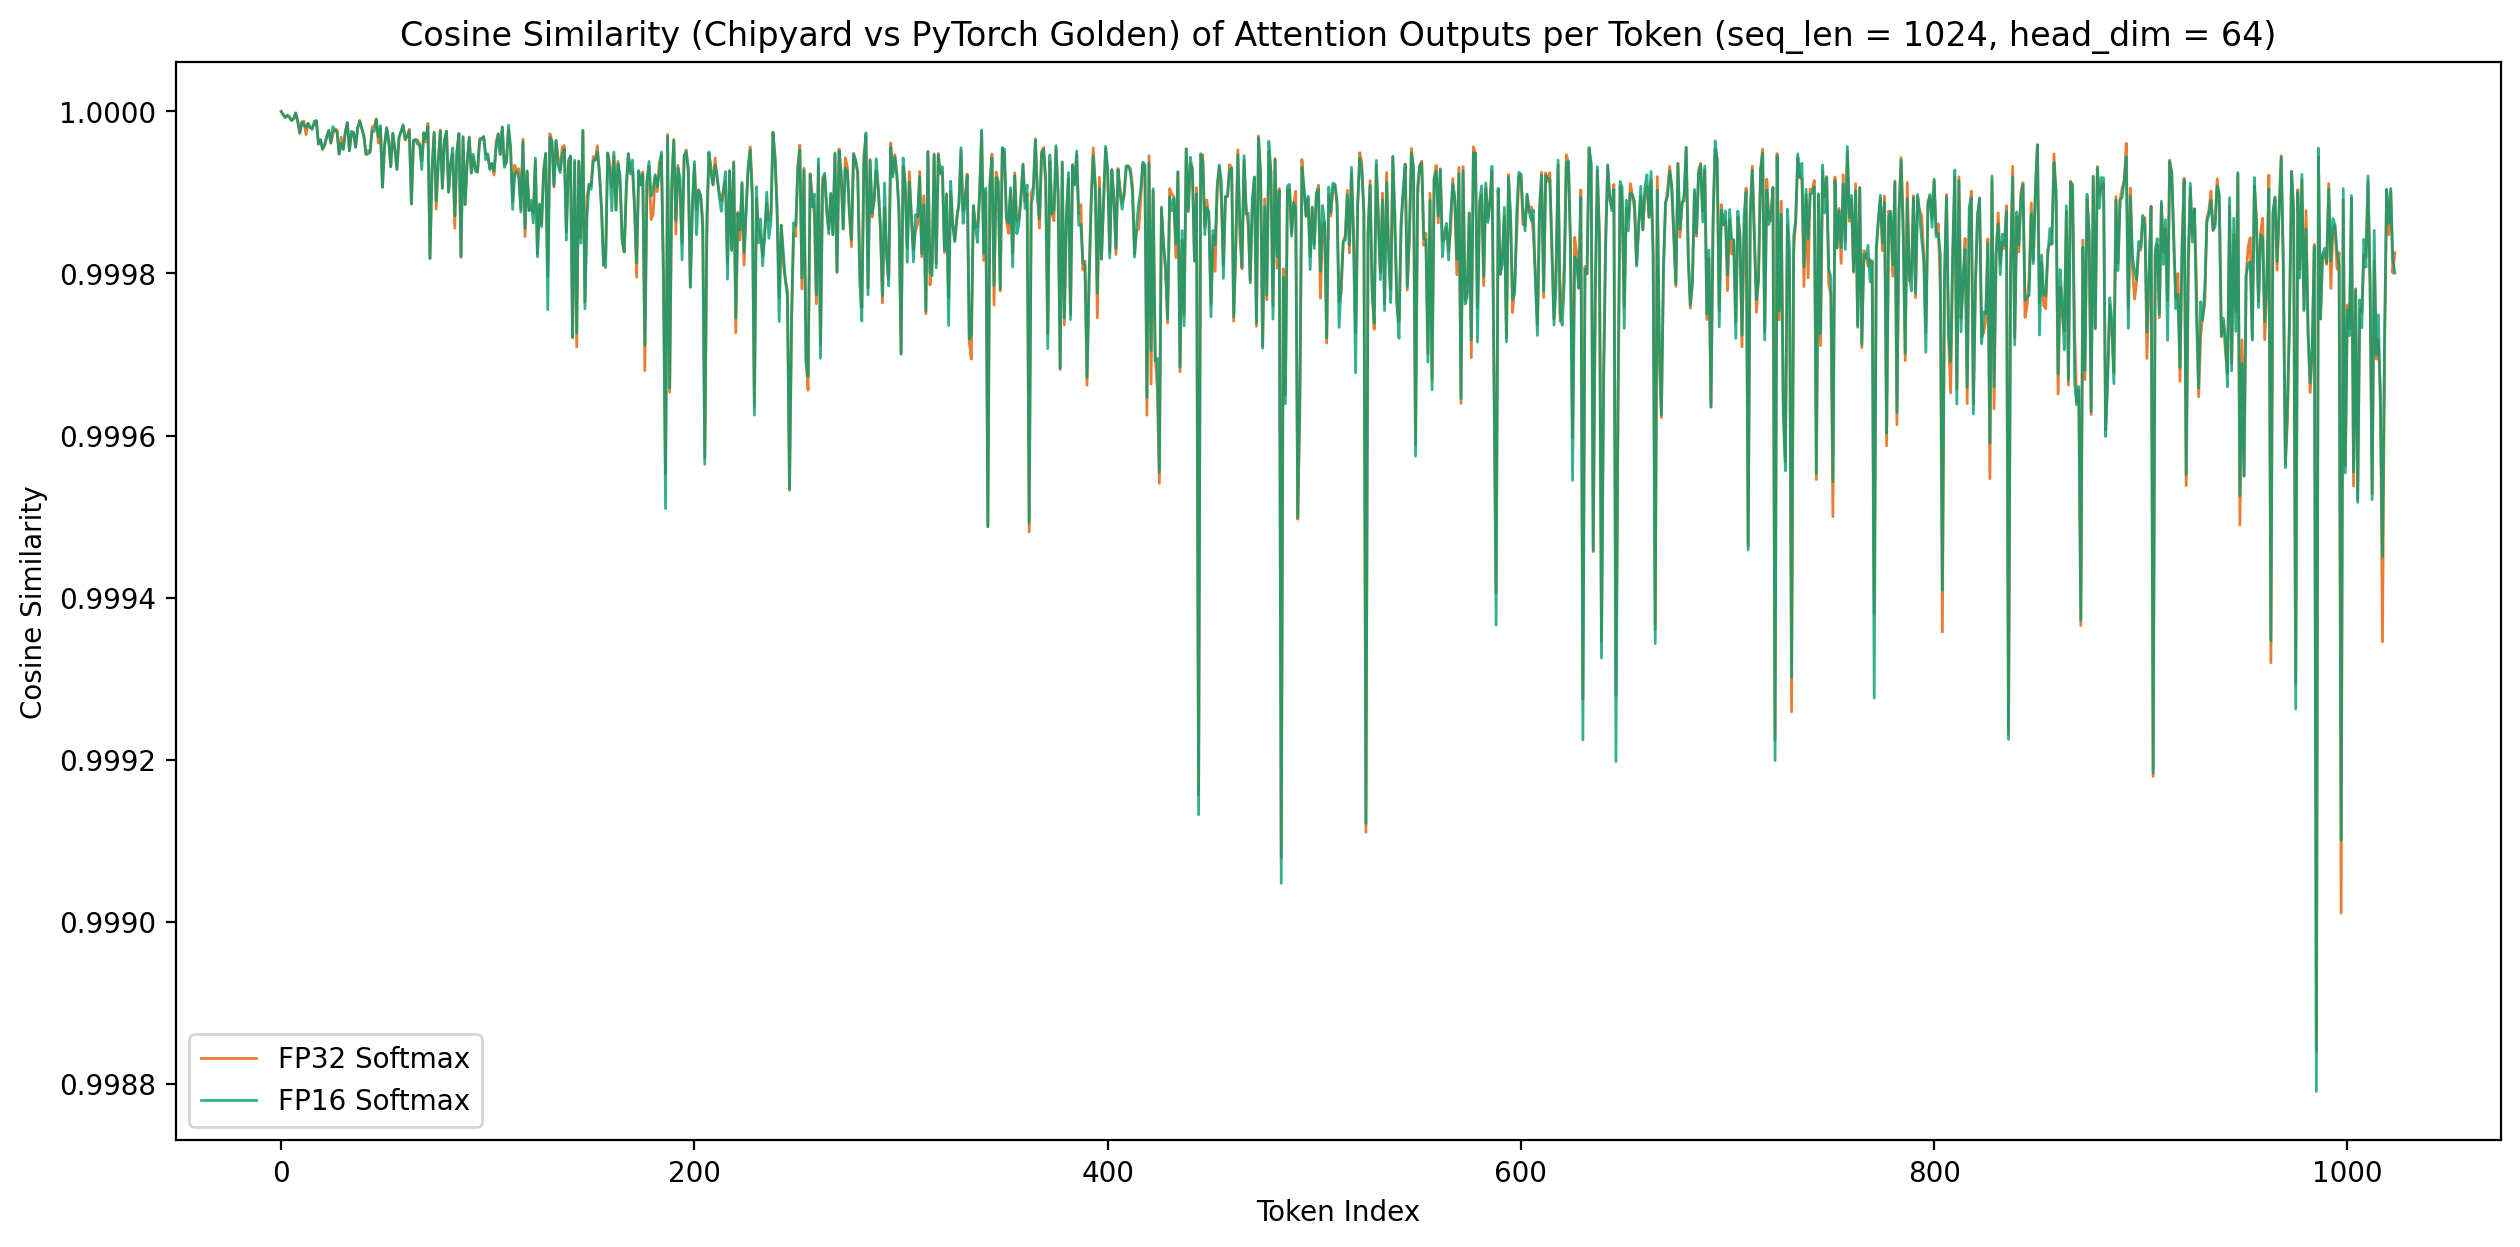

In [90]:
plt.figure(figsize=(15, 7), dpi=200)
plt.plot(O_c_fp32["seq1024_brbc128x256"].cos_similarity(O_golden_fp32["seq1024_brbc128x256"]), 
         label="FP32 Softmax",
         linewidth=1.0,
         alpha=0.8,
         color="#E65C00")
plt.plot(O_c_fp16["seq1024_brbc128x256"].cos_similarity(O_golden_fp16["seq1024_brbc128x256"]), 
         label="FP16 Softmax",
         linewidth=1.0, 
         alpha=0.8,
         color="#009E73")
plt.xlabel("Token Index")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity (Chipyard vs PyTorch Golden) of Attention Outputs per Token (seq_len = 1024, head_dim = 64)")
plt.legend()

print(f"Mean Cosine Similarity (FP32 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): {O_c_fp32['seq1024_brbc128x256'].cos_similarity(O_golden_fp32['seq1024_brbc128x256']).mean().item():.6f}")
print(f"Mean Cosine Similarity (FP16 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): {O_c_fp16['seq1024_brbc128x256'].cos_similarity(O_golden_fp32['seq1024_brbc128x256']).mean().item():.6f}")

### 2. Error Curve

#### 2.1 Relative Error

- Sequence Length 1k情况下的逐token相对误差曲线
- Tensor Level相对误差随Sequence Length的变化曲线

Tensor Level Relative Error (FP32 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): 0.012122
Tensor Level Relative Error (FP16 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): 0.012125


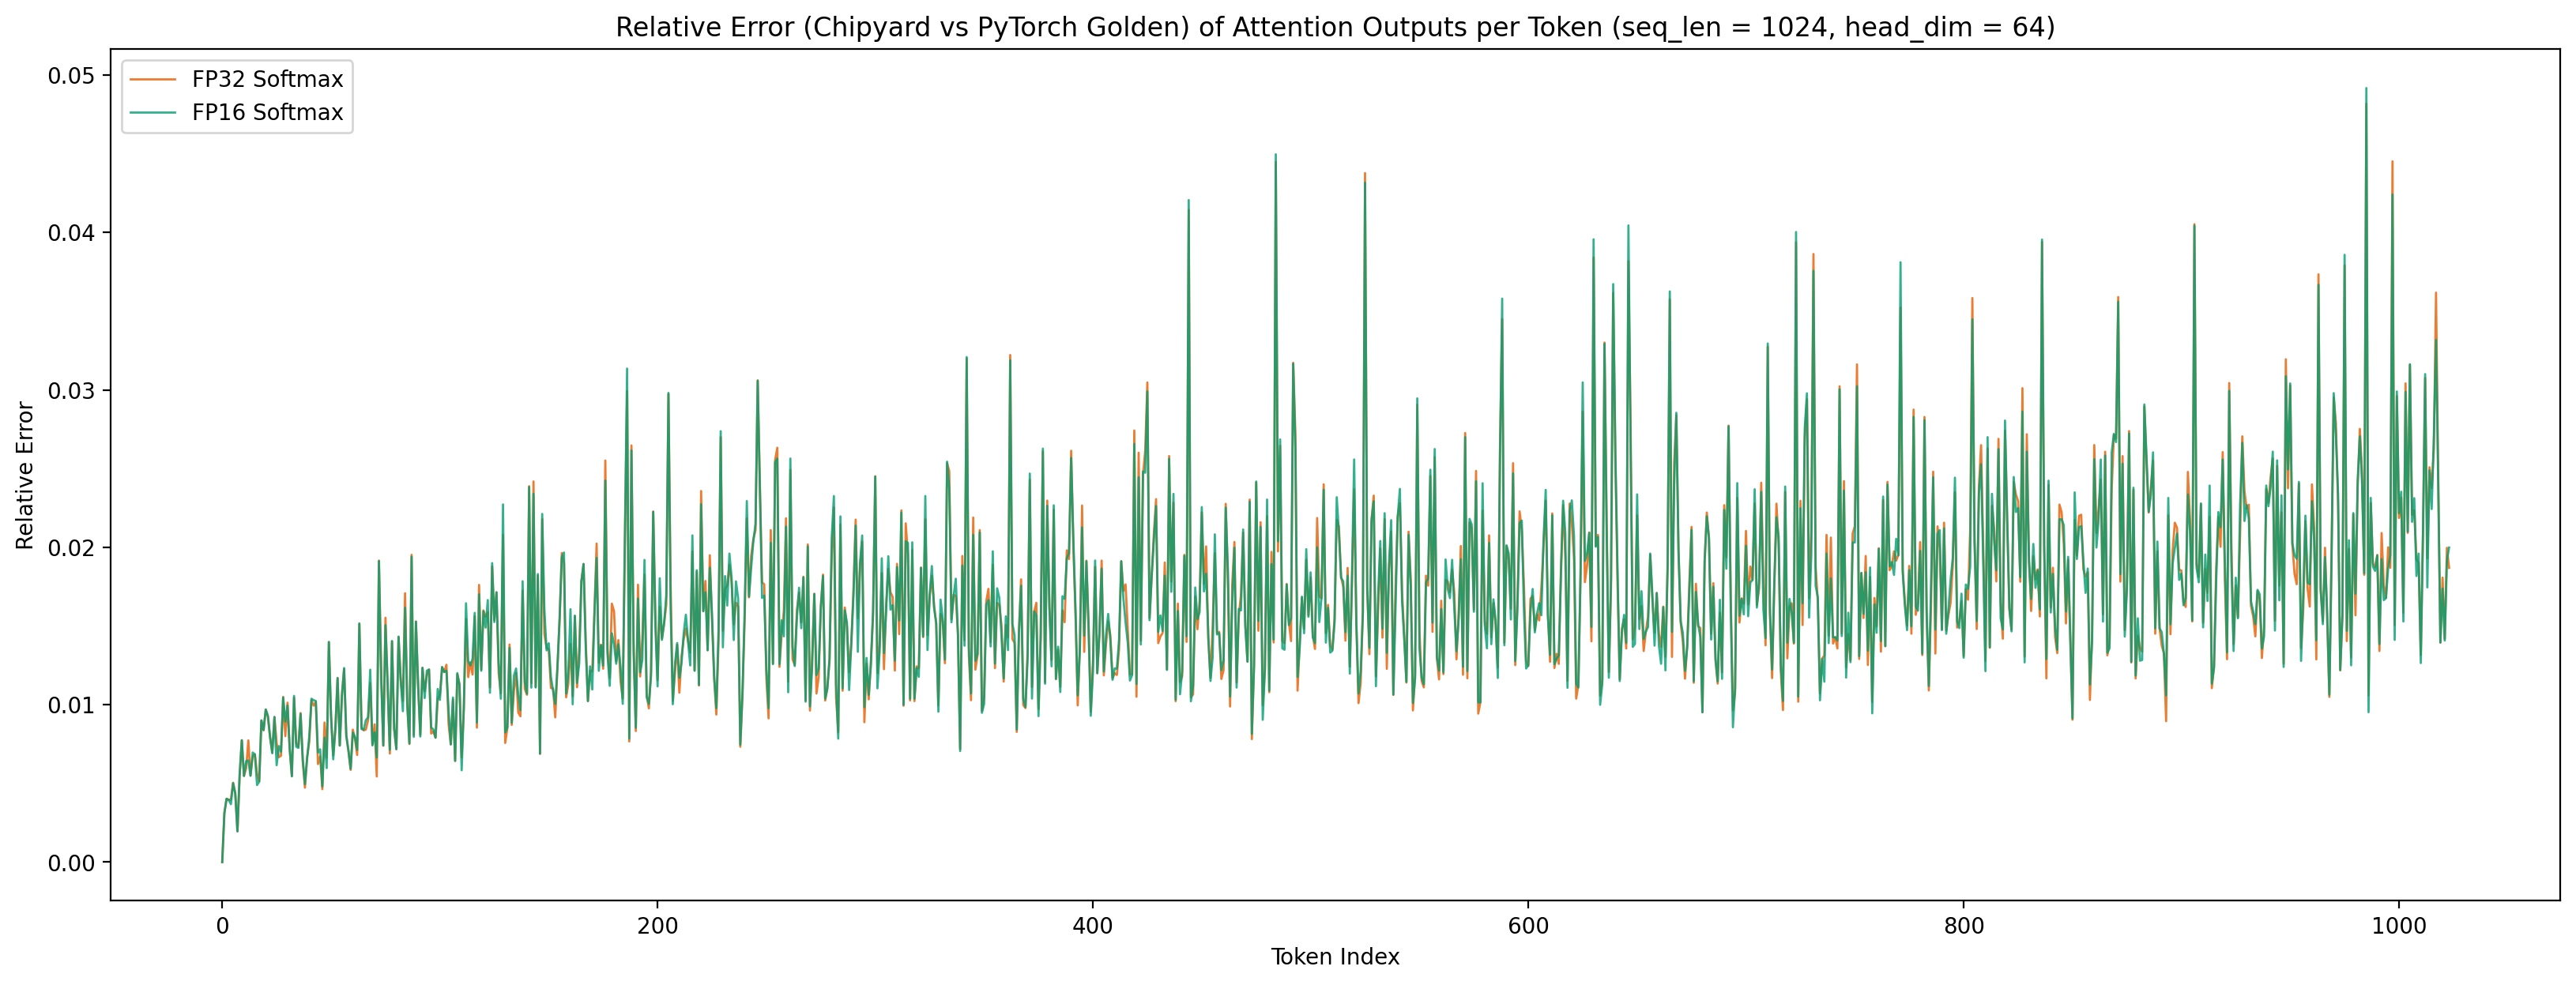

In [91]:
plt.figure(figsize=(20, 7), dpi=200)
plt.plot(O_c_fp32["seq1024_brbc128x256"].relative_error(O_golden_fp32["seq1024_brbc128x256"])[1],
         label="FP32 Softmax",
         linewidth=1.0,
         alpha=0.8,
         color="#E65C00")
plt.plot(O_c_fp16["seq1024_brbc128x256"].relative_error(O_golden_fp16["seq1024_brbc128x256"])[1],
         label="FP16 Softmax",
         linewidth=1.0, 
         alpha=0.8,
         color="#009E73")
plt.xlabel("Token Index")
plt.ylabel("Relative Error")
plt.title("Relative Error (Chipyard vs PyTorch Golden) of Attention Outputs per Token (seq_len = 1024, head_dim = 64)")
plt.legend()

print(f"Tensor Level Relative Error (FP32 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): {O_c_fp32['seq1024_brbc128x256'].relative_error(O_golden_fp32['seq1024_brbc128x256'])[0]:.6f}")
print(f"Tensor Level Relative Error (FP16 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): {O_c_fp16['seq1024_brbc128x256'].relative_error(O_golden_fp16['seq1024_brbc128x256'])[0]:.6f}")

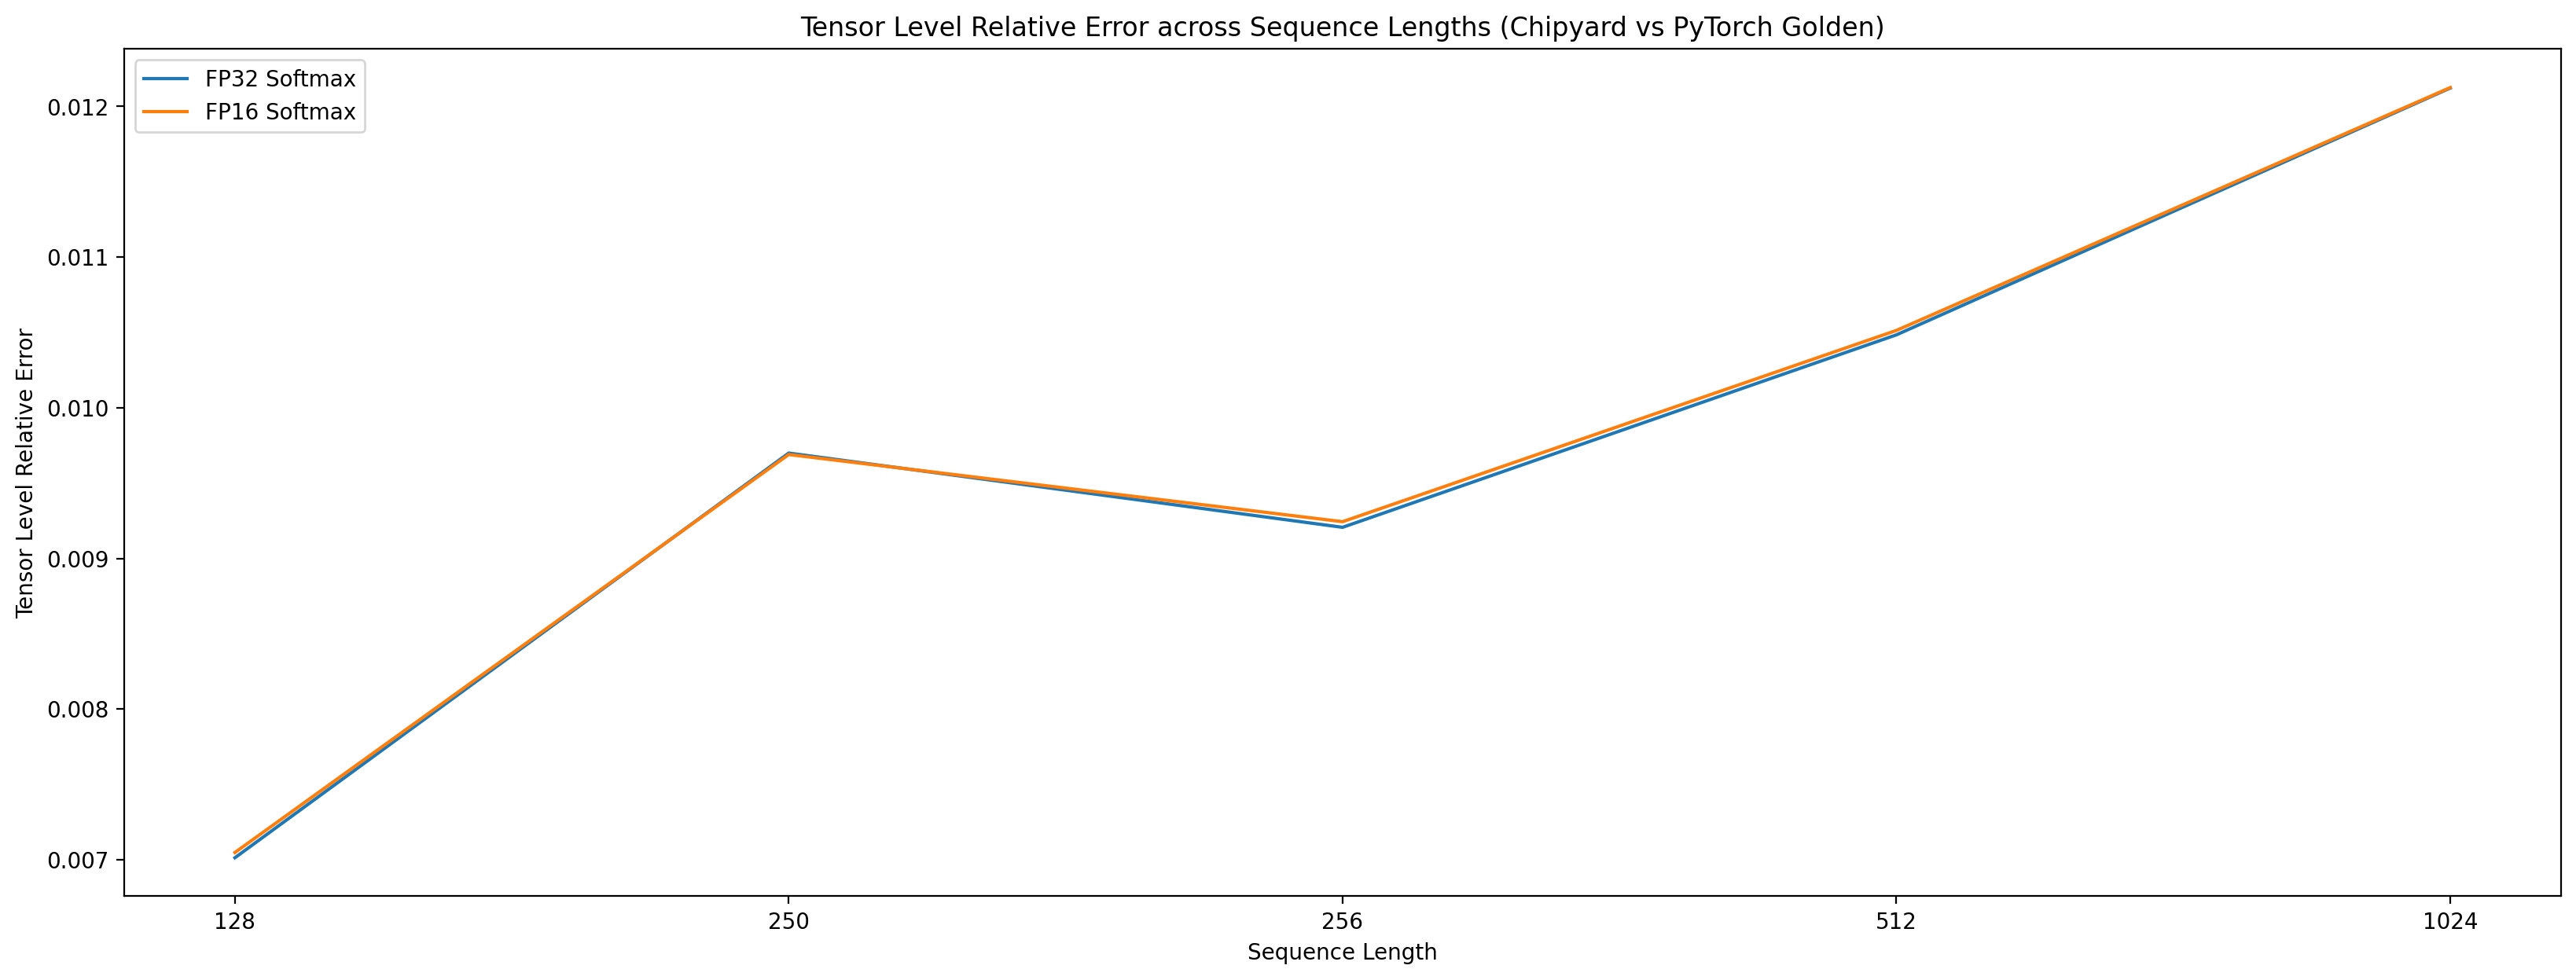

In [92]:
tensor_relative_error_c_golden_fp32 = {}
tensor_relative_error_c_golden_fp16 = {}

pairs = sorted(
    zip(O_c_fp32.items(), O_golden_fp32.items()),
    key=lambda pair: int(pair[0][0].split("_")[0].replace("seq", ""))
)

for (k_c, v_c), (k_golden, v_golden) in pairs:
    if "128x256" in k_c and k_c == k_golden:
        tensor_relative_error_c_golden_fp32[k_c.split("_")[0].replace("seq", "")] = v_c.relative_error(v_golden)[0]

pairs = sorted(
    zip(O_c_fp16.items(), O_golden_fp16.items()),
    key=lambda pair: int(pair[0][0].split("_")[0].replace("seq", ""))
)

for (k_c, v_c), (k_golden, v_golden) in pairs:
    if "128x256" in k_c and k_c == k_golden:
        tensor_relative_error_c_golden_fp16[k_c.split("_")[0].replace("seq", "")] = v_c.relative_error(v_golden)[0]

plt.figure(figsize=(20, 7), dpi=200)
plt.plot(list(tensor_relative_error_c_golden_fp32.keys()), list(tensor_relative_error_c_golden_fp32.values()),
         label="FP32 Softmax")
plt.plot(list(tensor_relative_error_c_golden_fp16.keys()), list(tensor_relative_error_c_golden_fp16.values()),
         label="FP16 Softmax")
plt.xlabel("Sequence Length")
plt.ylabel("Tensor Level Relative Error")
plt.title("Tensor Level Relative Error across Sequence Lengths (Chipyard vs PyTorch Golden)")
plt.legend()

#### 2.2 Max Absolute Error

与Relative Error可视化条件相同

Tensor Level Max Absolute Error (FP32 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): 0.019475
Tensor Level Max Absolute Error (FP16 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): 0.012210


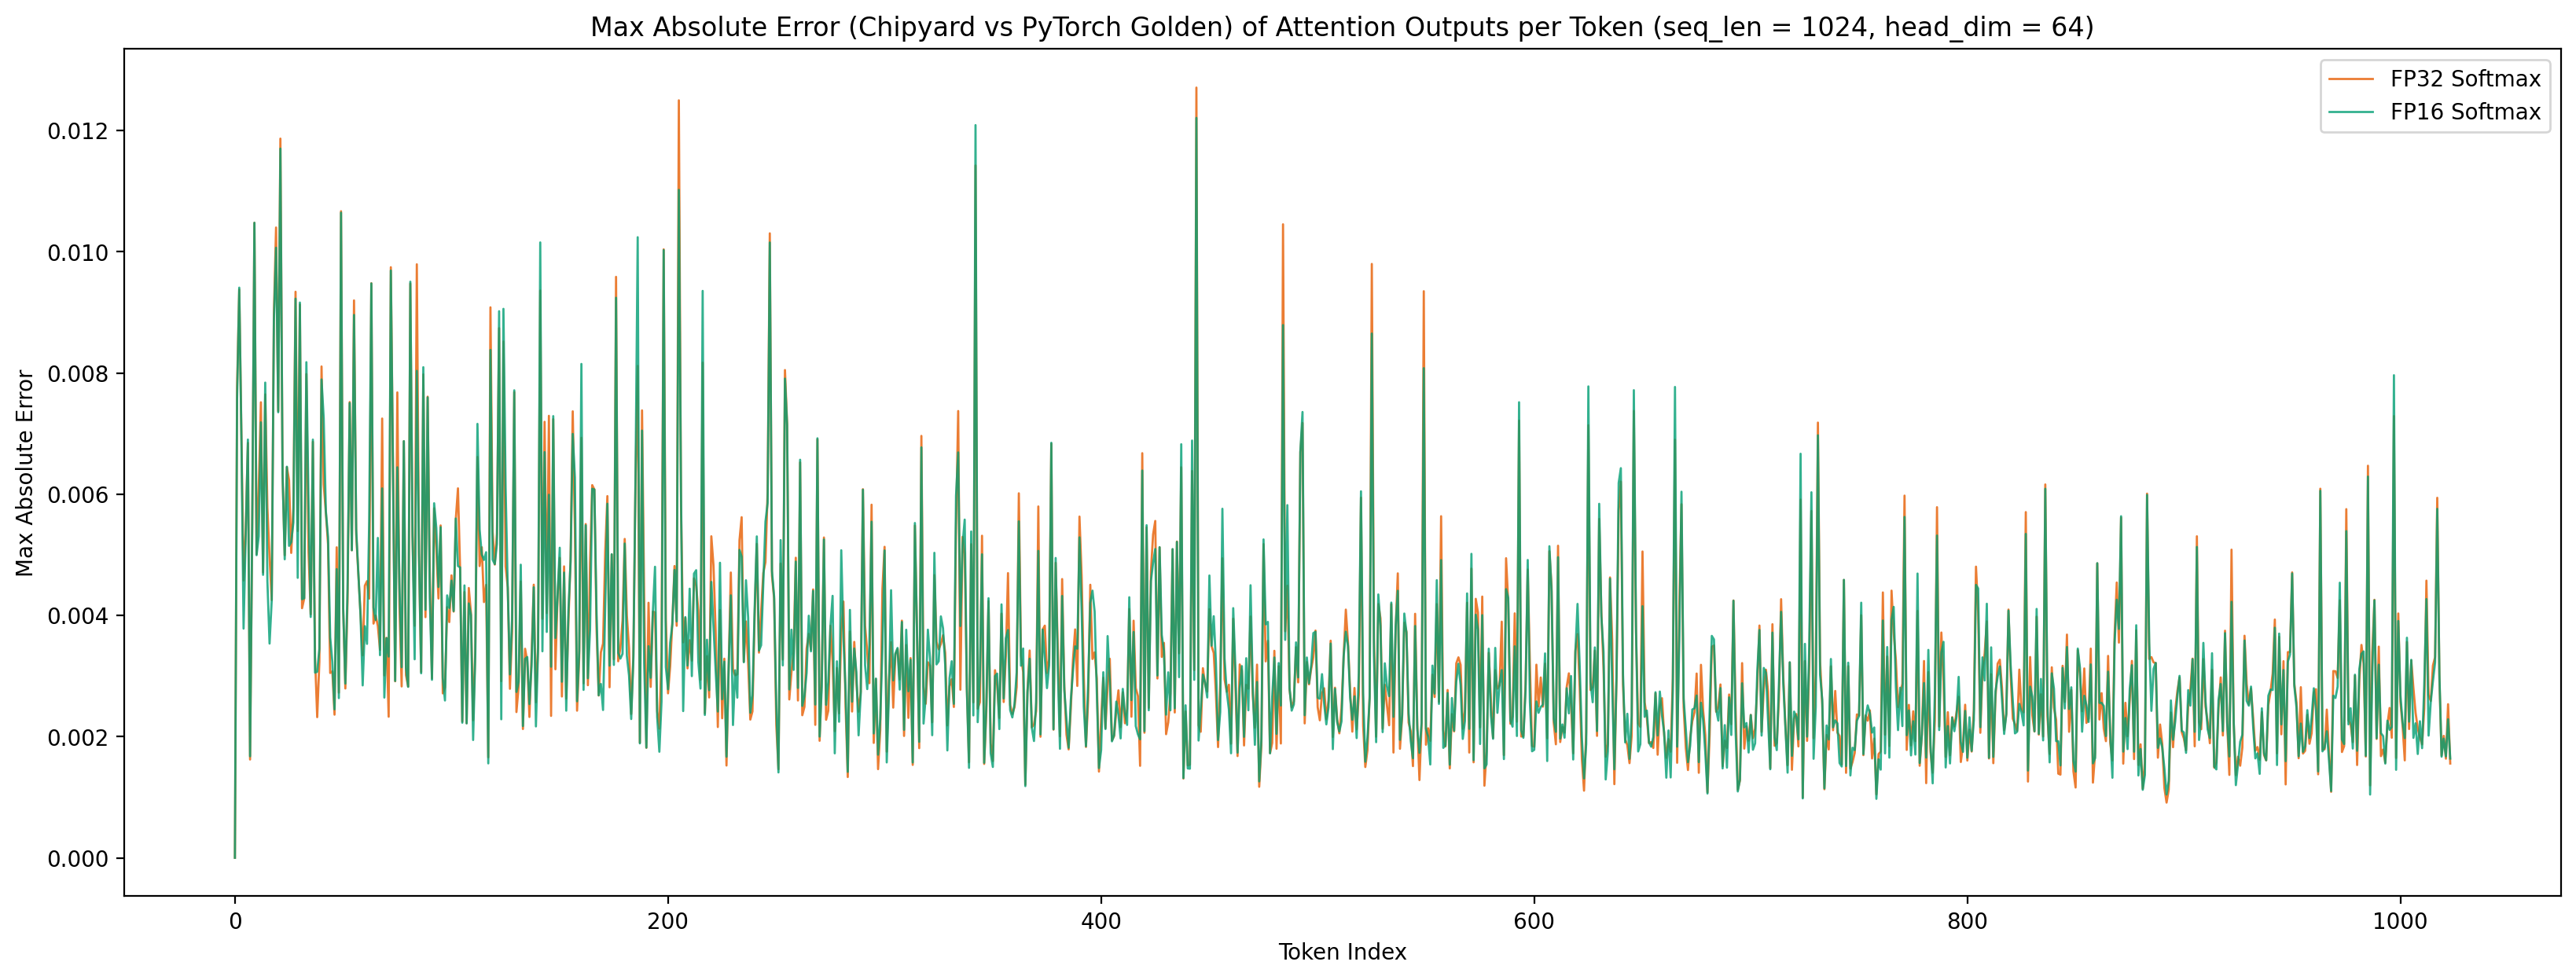

In [93]:
plt.figure(figsize=(20, 7), dpi=200)
plt.plot(O_c_fp32["seq1024_brbc128x256"].max_abs_error(O_golden_fp32["seq1024_brbc128x256"])[1],
         label="FP32 Softmax",
         linewidth=1.0,
         alpha=0.8,
         color="#E65C00")
plt.plot(O_c_fp16["seq1024_brbc128x256"].max_abs_error(O_golden_fp16["seq1024_brbc128x256"])[1],
         label="FP16 Softmax",
         linewidth=1.0,
         alpha=0.8,
         color="#009E73")
plt.xlabel("Token Index")
plt.ylabel("Max Absolute Error")
plt.title("Max Absolute Error (Chipyard vs PyTorch Golden) of Attention Outputs per Token (seq_len = 1024, head_dim = 64)")
plt.legend()

print(f"Tensor Level Max Absolute Error (FP32 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): {O_c_fp32['seq1024_brbc128x128'].max_abs_error(O_golden_fp32['seq1024_brbc128x128'])[0]:.6f}")
print(f"Tensor Level Max Absolute Error (FP16 Softmax vs PyTorch Golden) (seq_len = 1024, head_dim = 64): {O_c_fp16['seq1024_brbc128x256'].max_abs_error(O_golden_fp16['seq1024_brbc128x256'])[0]:.6f}")

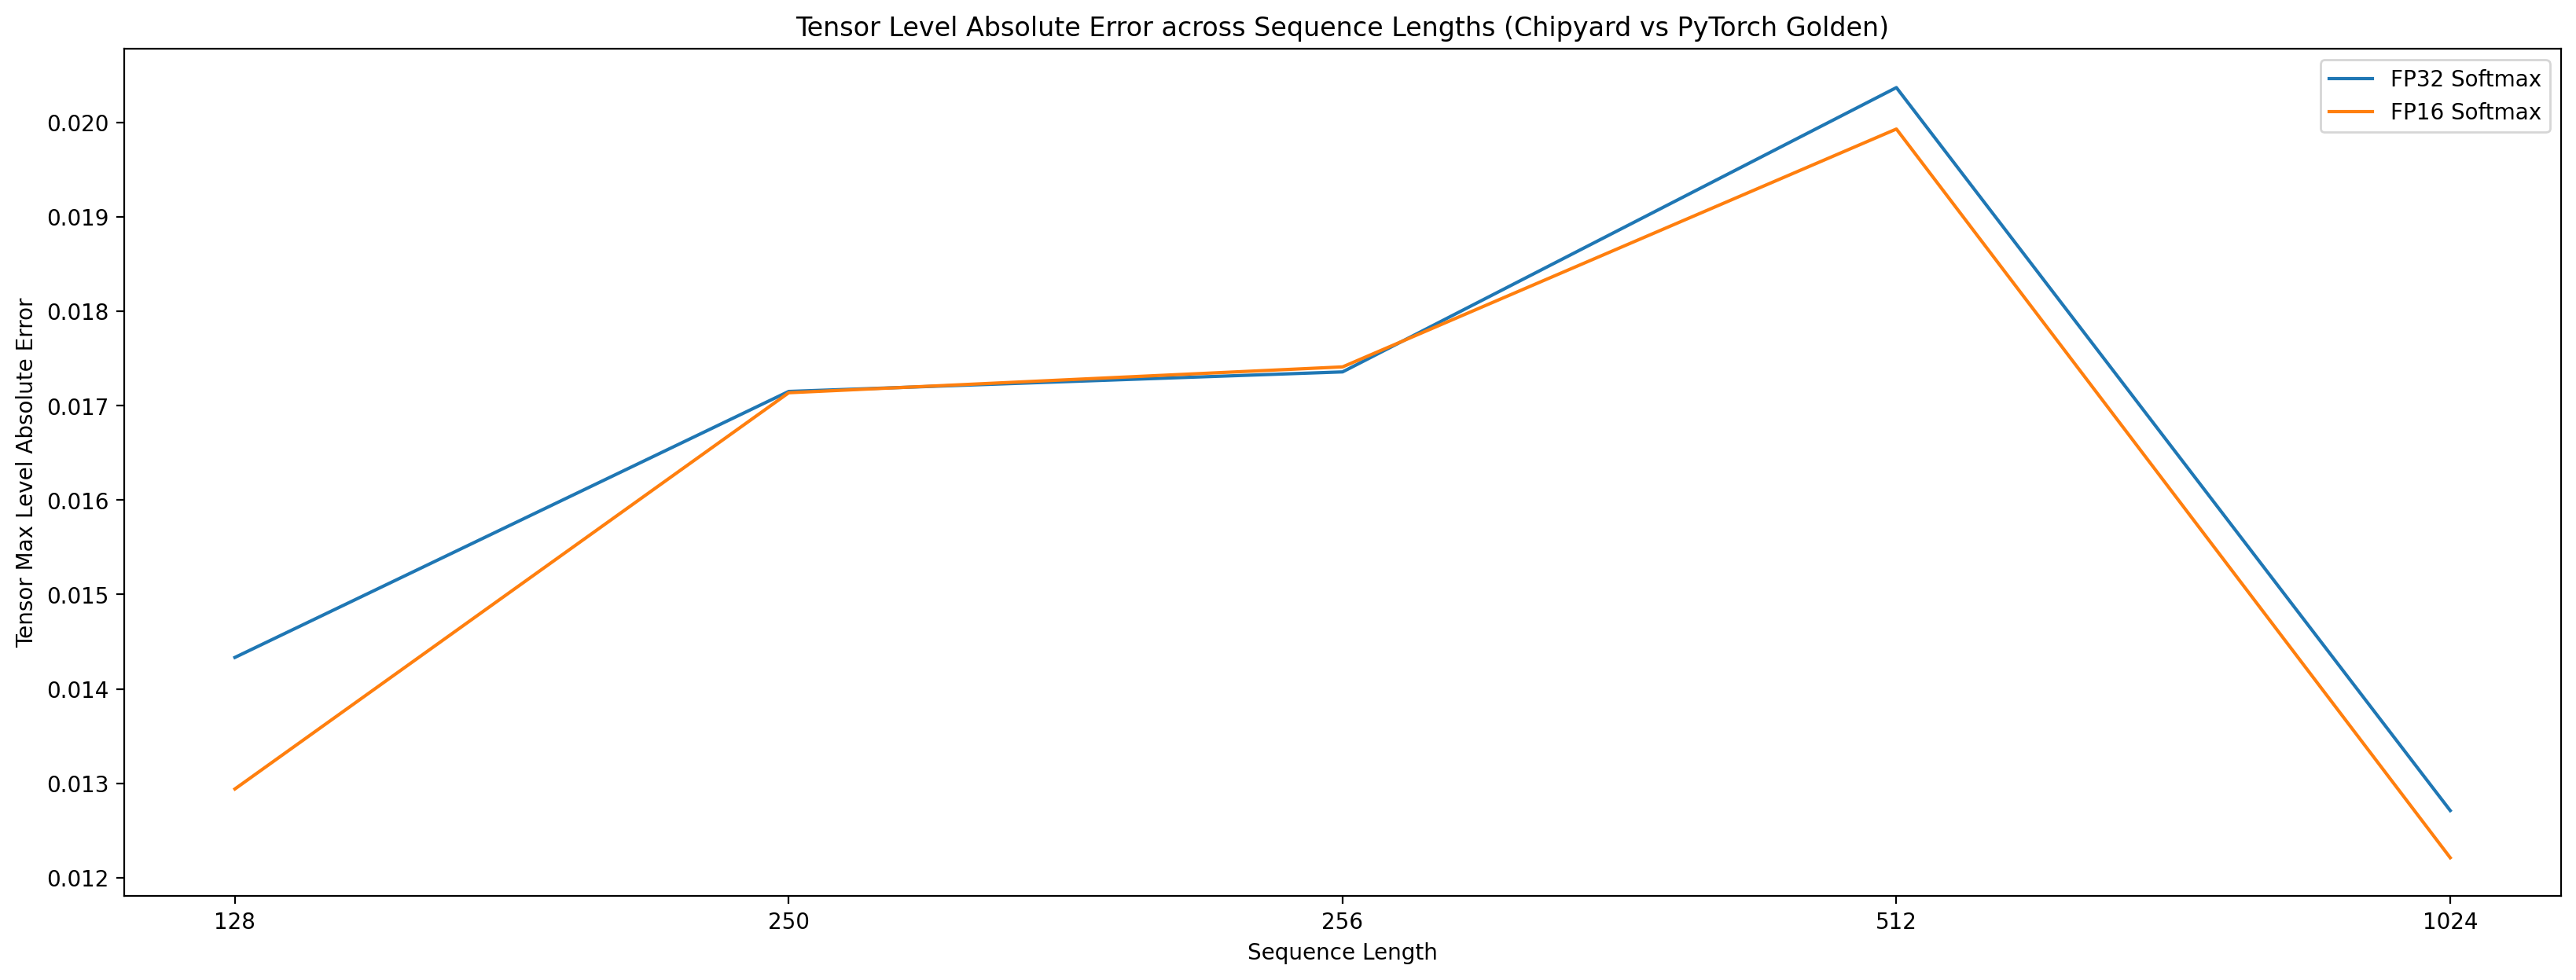

In [94]:
tensor_abs_error_c_golden_fp32 = {}
tensor_abs_error_c_golden_fp16 = {}

pairs = sorted(
    zip(O_c_fp32.items(), O_golden_fp32.items()),
    key=lambda pair: int(pair[0][0].split("_")[0].replace("seq", ""))
)

for (k_c, v_c), (k_golden, v_golden) in pairs:
    if "128x256" in k_c and k_c == k_golden:
        tensor_abs_error_c_golden_fp32[k_c.split("_")[0].replace("seq", "")] = v_c.max_abs_error(v_golden)[0]

pairs = sorted(
    zip(O_c_fp16.items(), O_golden_fp16.items()),
    key=lambda pair: int(pair[0][0].split("_")[0].replace("seq", ""))
)

for (k_c, v_c), (k_golden, v_golden) in pairs:
    if "128x256" in k_c and k_c == k_golden:
        tensor_abs_error_c_golden_fp16[k_c.split("_")[0].replace("seq", "")] = v_c.max_abs_error(v_golden)[0]

plt.figure(figsize=(20, 7), dpi=200)
plt.plot(list(tensor_abs_error_c_golden_fp32.keys()), list(tensor_abs_error_c_golden_fp32.values()),
         label="FP32 Softmax")
plt.plot(list(tensor_abs_error_c_golden_fp16.keys()), list(tensor_abs_error_c_golden_fp16.values()),
         label="FP16 Softmax")
plt.xlabel("Sequence Length")
plt.ylabel("Tensor Max Level Absolute Error")
plt.title("Tensor Level Absolute Error across Sequence Lengths (Chipyard vs PyTorch Golden)")
plt.legend()

### 3. Outputs Distribution

Sequence Length为1k情况下的输出数据分布情况

The max, min and mean value of FP32 Chipyard output (seq_len = 1024, head_dim = 64): max=2.102184, min=-3.818967, mean=-0.004400
The max, min and mean value of FP16 Chipyard output (seq_len = 1024, head_dim = 64): max=2.102184, min=-3.818967, mean=-0.004401
The max, min and mean value of PyTorch Golden output (seq_len = 1024, head_dim = 64): max=2.102184, min=-3.818967, mean=-0.004395


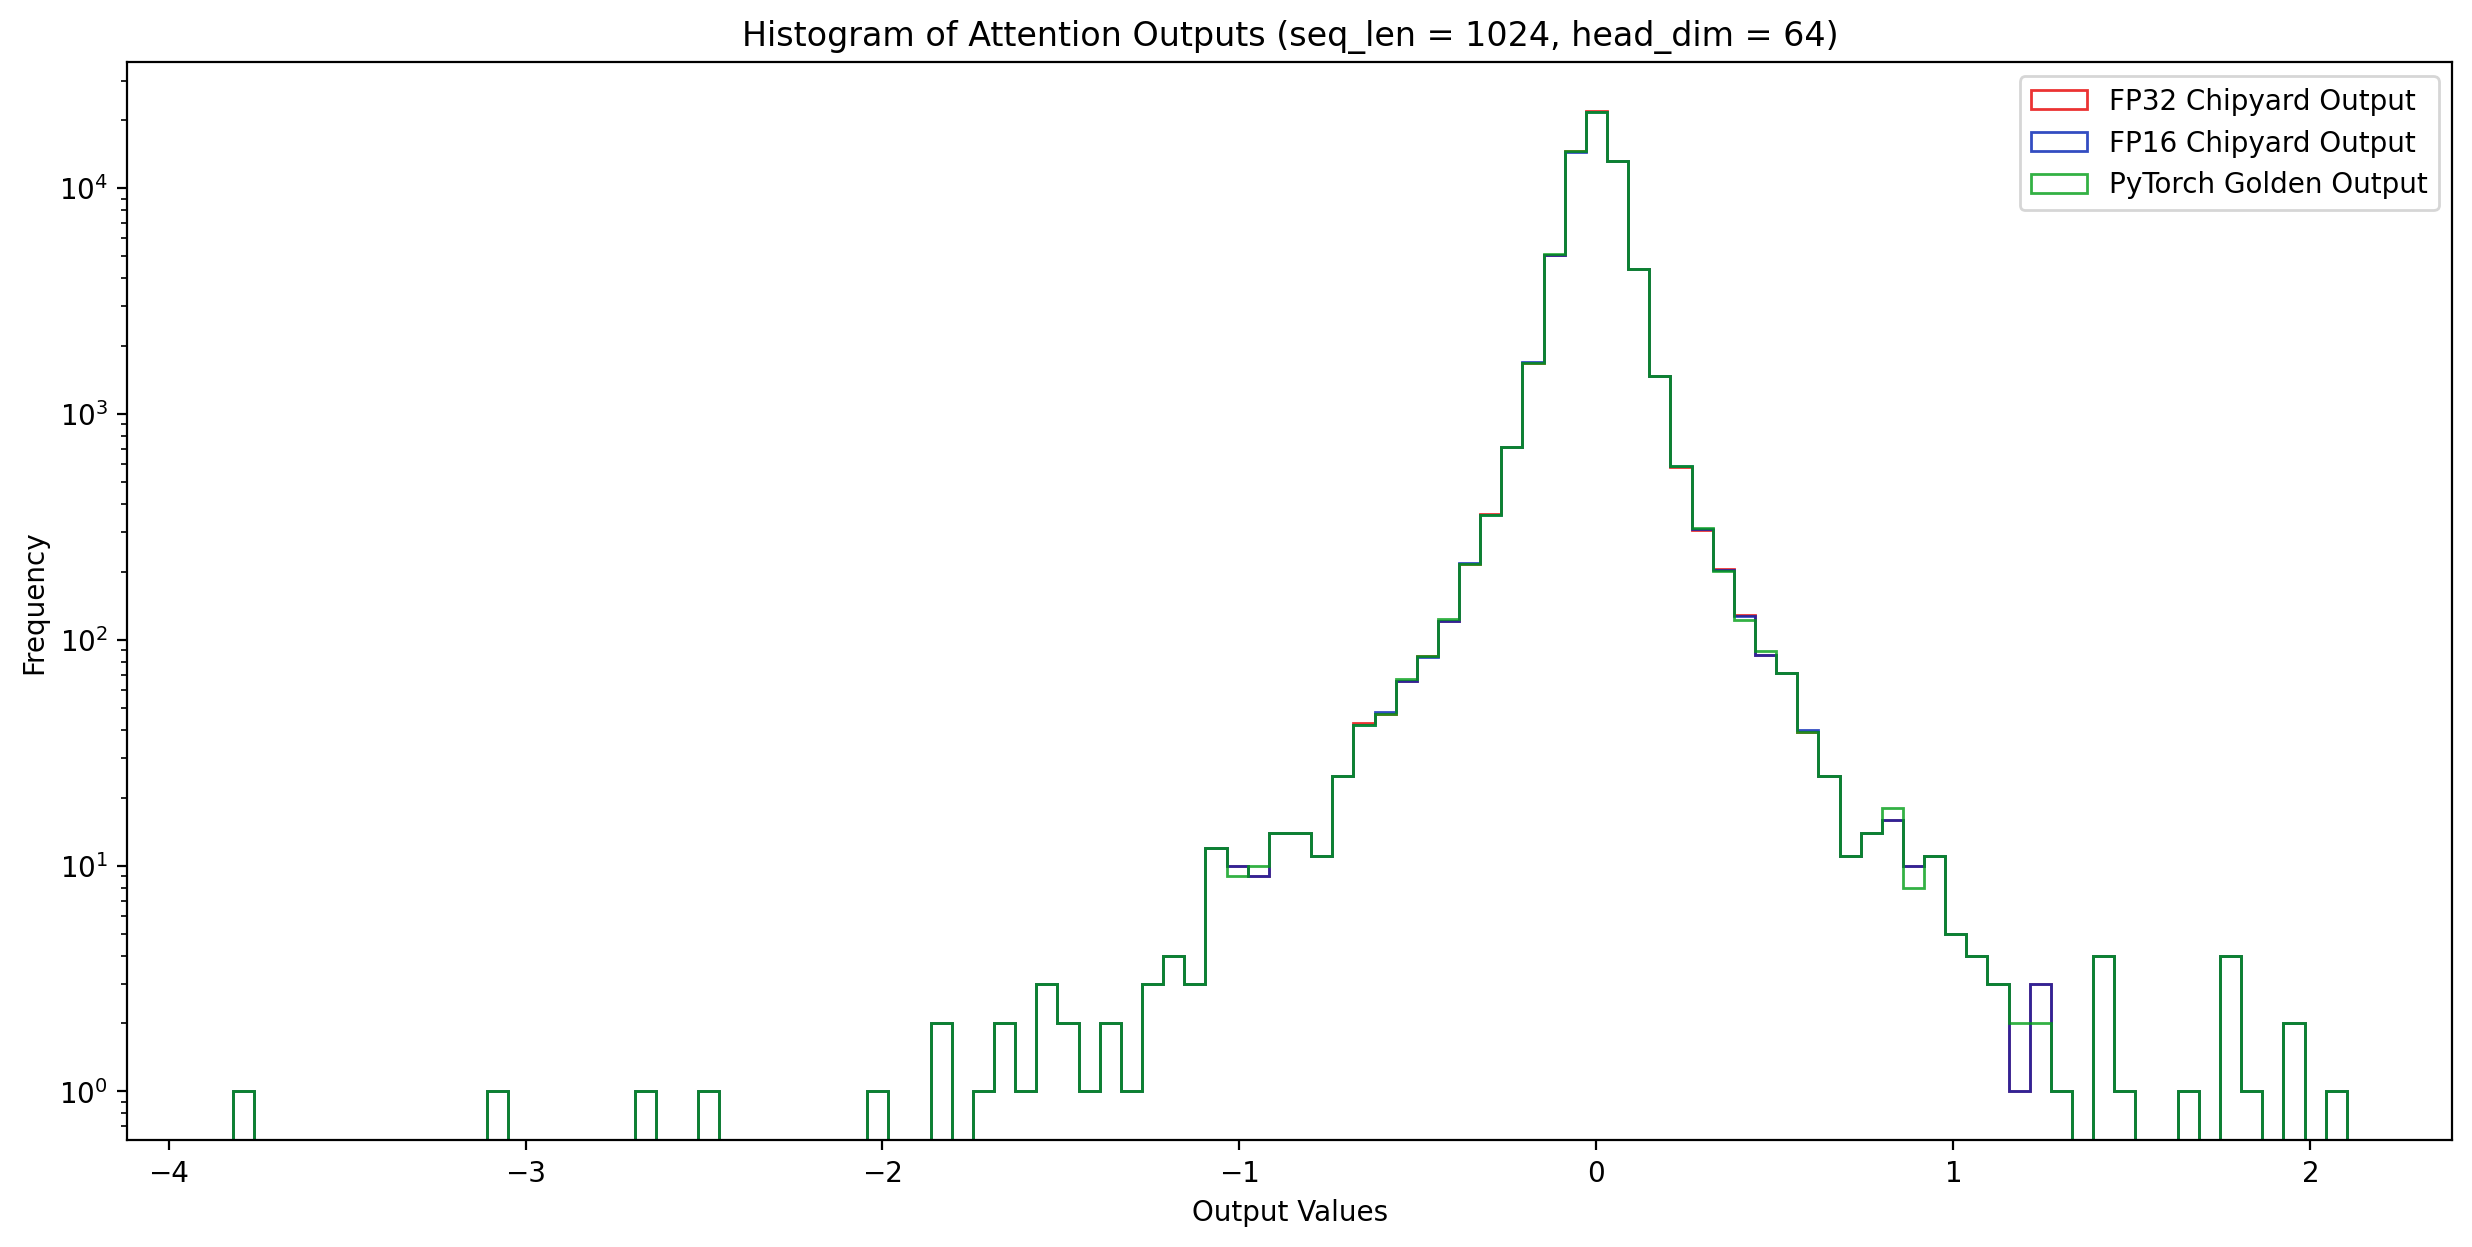

In [95]:
plt.figure(figsize=(15, 7), dpi=200)
plt.hist(O_c_fp32["seq1024_brbc128x256"].tensor.flatten().numpy(), 
         bins=100, 
         alpha=0.8, 
         label="FP32 Chipyard Output", 
         color="#E60000",
         log=True,
         histtype="step")
plt.hist(O_c_fp16["seq1024_brbc128x256"].tensor.flatten().numpy(), 
         bins=100, 
         alpha=0.8, 
         label="FP16 Chipyard Output", 
         color="#0021B2",
         log=True,
         histtype="step")
plt.hist(O_golden_fp32["seq1024_brbc128x256"].tensor.flatten().numpy(), 
         bins=100, 
         alpha=0.8, 
         label="PyTorch Golden Output", 
         color="#009E15",
         log=True,
         histtype="step")
plt.xlabel("Output Values")
plt.ylabel("Frequency")
plt.title("Histogram of Attention Outputs (seq_len = 1024, head_dim = 64)")
plt.legend()

print(f"The max, min and mean value of FP32 Chipyard output (seq_len = 1024, head_dim = 64): max={O_c_fp32['seq1024_brbc128x256'].tensor.max().item():.6f}, min={O_c_fp32['seq1024_brbc128x256'].tensor.min().item():.6f}, mean={O_c_fp32['seq1024_brbc128x256'].tensor.mean().item():.6f}")
print(f"The max, min and mean value of FP16 Chipyard output (seq_len = 1024, head_dim = 64): max={O_c_fp16['seq1024_brbc128x256'].tensor.max().item():.6f}, min={O_c_fp16['seq1024_brbc128x256'].tensor.min().item():.6f}, mean={O_c_fp16['seq1024_brbc128x256'].tensor.mean().item():.6f}")
print(f"The max, min and mean value of PyTorch Golden output (seq_len = 1024, head_dim = 64): max={O_golden_fp32['seq1024_brbc128x256'].tensor.max().item():.6f}, min={O_golden_fp32['seq1024_brbc128x256'].tensor.min().item():.6f}, mean={O_golden_fp32['seq1024_brbc128x256'].tensor.mean().item():.6f}")

### C vs Python Model

验证Python C Model与Chipyard实现是否完全一致

In [96]:
print("FP16 Similarity\n")
print(f"Mean Cosine Similarity (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_c_fp16['seq1024_brbc128x256'].cos_similarity(O_python_fp16['seq1024_brbc128x256']).mean().item():.6f}")
print(f"Tensor Level Relative Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_c_fp16['seq1024_brbc128x256'].relative_error(O_python_fp16['seq1024_brbc128x256'])[0]:.6f}")
print(f"Tensor Level Max Absolute Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_c_fp16['seq1024_brbc128x256'].max_abs_error(O_python_fp16['seq1024_brbc128x256'])[0]:.6f}")

print(f"\nMean Cosine Similarity (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_python_fp16['seq1024_brbc128x256'].cos_similarity(O_golden_fp16['seq1024_brbc128x256']).mean().item():.6f}")
print(f"Tensor Level Relative Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_python_fp16['seq1024_brbc128x256'].relative_error(O_golden_fp16['seq1024_brbc128x256'])[0]:.6f}")
print(f"Tensor Level Max Absolute Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_python_fp16['seq1024_brbc128x256'].max_abs_error(O_golden_fp16['seq1024_brbc128x256'])[0]:.6f}")

FP16 Similarity

Mean Cosine Similarity (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 1.000000
Tensor Level Relative Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.000031
Tensor Level Max Absolute Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.000099

Mean Cosine Similarity (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.999844
Tensor Level Relative Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.012125
Tensor Level Max Absolute Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.012210


In [97]:
print("FP32 Similarity\n")
print(f"Mean Cosine Similarity (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_c_fp32['seq1024_brbc128x256'].cos_similarity(O_python_fp32['seq1024_brbc128x256']).mean().item():.6f}")
print(f"Tensor Level Relative Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_c_fp32['seq1024_brbc128x256'].relative_error(O_python_fp32['seq1024_brbc128x256'])[0]:.6f}")
print(f"Tensor Level Max Absolute Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_c_fp32['seq1024_brbc128x256'].max_abs_error(O_python_fp32['seq1024_brbc128x256'])[0]:.6f}")

print(f"\nMean Cosine Similarity (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_python_fp32['seq1024_brbc128x256'].cos_similarity(O_golden_fp32['seq1024_brbc128x256']).mean().item():.6f}")
print(f"Tensor Level Relative Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_python_fp32['seq1024_brbc128x256'].relative_error(O_golden_fp32['seq1024_brbc128x256'])[0]:.6f}")
print(f"Tensor Level Max Absolute Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): {O_python_fp32['seq1024_brbc128x256'].max_abs_error(O_golden_fp32['seq1024_brbc128x256'])[0]:.6f}")

FP32 Similarity

Mean Cosine Similarity (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 1.000000
Tensor Level Relative Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.000001
Tensor Level Max Absolute Error (C vs Python) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.000001

Mean Cosine Similarity (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.999844
Tensor Level Relative Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.012122
Tensor Level Max Absolute Error (Python vs Golden) (seq_len = 1024, br = 128, bc = 256, head_dim = 64): 0.012710
